# 02 ? flat training

**Objective:** Configure, launch and monitor one validation-selected EfficientNet-B0 reproduction run.

**Experiment:** Historical Flat versus Shared-Hard baseline reconstruction, seed 42.

**Config:** `configs/experiments/flat/efficientnet_b0.yaml`

**Inputs:** Config, verified train/validation images; last checkpoint only when explicitly resuming.

**Outputs:** Run snapshot/environment/history/logs, immutable best.pt and last.pt generations, registry events.

**Mode:** Training workflow; opt-in disabled by default. Every input is loaded from disk; no other notebook's kernel state is required.

Use **Restart Kernel ? Run All**. Real training is disabled until the build handover is reviewed.


In [1]:
from pathlib import Path
import sys, os
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs/protocol.yaml").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display, Markdown
from src.config import load_config
DATA_ROOT = os.environ.get("SKIN_CANCER_DATA_ROOT")
print("Dataset root:", Path(DATA_ROOT).expanduser().resolve() if DATA_ROOT else "NOT CONFIGURED ? set SKIN_CANCER_DATA_ROOT before image verification/training")


Dataset root: /home/m-sazzad-h/skin-cancer-work


In [2]:
CONFIG_PATH = "configs/experiments/flat/efficientnet_b0.yaml"
config = load_config(CONFIG_PATH)
display(config)

{'protocol_version': 'full30_baseline_v1',
 'seed': 42,
 'pretrained': 'imagenet',
 'dropout': 0.2,
 'classes': ['non_malignant', 'melanoma', 'bcc', 'scc'],
 'manifests': {'isic': 'data/manifests/isic2019_train_val_test_split_seed42.csv',
  'stage3': 'data/manifests/emb_stage03_dermoscopic_split_seed42.csv'},
 'expected_counts': {'isic': {'train': 17124,
   'validation': 3668,
   'test': 3668},
  'stage3': {'train': 594, 'validation': 127, 'test': 127}},
 'transforms': {'size': 224,
  'resize': 256,
  'crop_scale': [0.85, 1.0],
  'crop_ratio': [0.9, 1.1],
  'flip': 0.5,
  'rotation': 15.0,
  'jitter': [0.1, 0.1, 0.1, 0.02],
  'mean': [0.485, 0.456, 0.406],
  'std': [0.229, 0.224, 0.225]},
 'loader': {'batch_size': 64,
  'workers': 4,
  'pin_memory': True,
  'persistent_workers': True,
  'prefetch_factor': 2},
 'losses': {'flat': 'cross_entropy',
  'task1': 'cross_entropy',
  'task2': 'class_balanced_focal',
  'task3': 'weighted_cross_entropy',
  'beta': 0.9999,
  'gamma': 2.0,
  'task_

## Launch controls

After explicit Azure training authorization, set `RUN_TRAINING=True`. Use `RESUME=True` only for an interrupted run. A completed run cannot be overwritten. Other backbones remain locked until the EfficientNet-B0 comparison is reviewed.

In [3]:
RUN_TRAINING = True
RESUME = False
DEVICE = "cuda"
from src.training import train
result = train(config, data_root=DATA_ROOT, allow_training=RUN_TRAINING, resume=RESUME, device=DEVICE)
display(result)

Dataset root: /home/m-sazzad-h/skin-cancer-work
{"epoch": 1, "learning_rate": 0.0003, "train_loss": 0.567178888205083, "train_task1_loss": null, "train_task2_loss": null, "train_task3_loss": null, "val_validation_macro_f1": 0.620898847744706, "selection_score": 0.620898847744706, "patience_counter": 0}
{"epoch": 2, "learning_rate": 0.0002991810233575568, "train_loss": 0.41234464477682414, "train_task1_loss": null, "train_task2_loss": null, "train_task3_loss": null, "val_validation_macro_f1": 0.6498478479818902, "selection_score": 0.6498478479818902, "patience_counter": 0}
{"epoch": 3, "learning_rate": 0.0002967330663097039, "train_loss": 0.3562150757130661, "train_task1_loss": null, "train_task2_loss": null, "train_task3_loss": null, "val_validation_macro_f1": 0.6173763462732935, "selection_score": 0.6173763462732935, "patience_counter": 1}
{"epoch": 4, "learning_rate": 0.0002926829491861254, "train_loss": 0.30104452280749283, "train_task1_loss": null, "train_task2_loss": null, "train_

{'experiment_id': 'flat_efficientnet_b0_seed42',
 'architecture': 'efficientnet_b0',
 'system_type': 'flat',
 'seed': 42,
 'config_path': 'configs/experiments/flat/efficientnet_b0.yaml',
 'manifest_hash': 'bba1b8c962cc8b492afa09bdde517572690d764a4fc61d0200b19fe341ba824e',
 'start_time': '2026-09-10T17:48:18.194325+00:00',
 'end_time': '2026-09-10T18:35:51.693969+00:00',
 'best_epoch': 5,
 'selection_metric': 'validation_macro_f1',
 'best_validation_score': 0.6504898607805603,
 'checkpoint_path': 'models/checkpoints/flat_efficientnet_b0_seed42/epoch_005_dd7f1ae1/best.pt',
 'status': 'completed'}

## Monitor and inspect checkpoint references

Re-run this cell to reload the current disk history. Validation selects the model; no internal-test predictions enter training.

{'experiment_id': 'flat_efficientnet_b0_seed42',
 'architecture': 'efficientnet_b0',
 'system_type': 'flat',
 'seed': 42,
 'config_path': 'configs/experiments/flat/efficientnet_b0.yaml',
 'manifest_hash': 'bba1b8c962cc8b492afa09bdde517572690d764a4fc61d0200b19fe341ba824e',
 'start_time': '2026-09-10T17:48:18.194325+00:00',
 'end_time': '2026-09-10T18:35:51.693969+00:00',
 'best_epoch': 5,
 'selection_metric': 'validation_macro_f1',
 'best_validation_score': 0.6504898607805603,
 'checkpoint_path': 'models/checkpoints/flat_efficientnet_b0_seed42/epoch_005_dd7f1ae1/best.pt',
 'status': 'completed'}

,epoch,learning_rate,train_loss,train_task1_loss,train_task2_loss,train_task3_loss,val_validation_macro_f1,selection_score,patience_counter
0,1,0.000300,0.567179,NaN,NaN,NaN,0.620899,0.620899,0
1,2,0.000299,0.412345,NaN,NaN,NaN,0.649848,0.649848,0
2,3,0.000297,0.356215,NaN,NaN,NaN,0.617376,0.617376,1
3,4,0.000293,0.301045,NaN,NaN,NaN,0.625173,0.625173,2
4,5,0.000287,0.246575,NaN,NaN,NaN,0.650490,0.650490,0
5,6,0.000280,0.213459,NaN,NaN,NaN,0.590188,0.590188,1
6,7,0.000271,0.179754,NaN,NaN,NaN,0.633612,0.633612,2
7,8,0.000262,0.163035,NaN,NaN,NaN,0.620271,0.620271,3
8,9,0.000251,0.135418,NaN,NaN,NaN,0.629796,0.629796,4
9,10,0.000238,0.113285,NaN,NaN,NaN,0.601160,0.601160,5


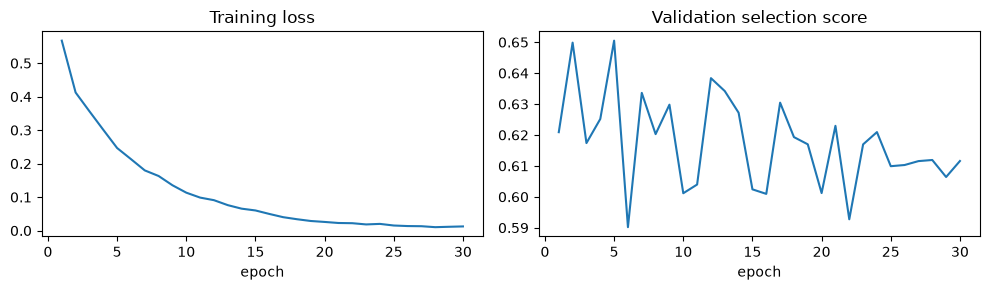

{'last': {'path': 'models/checkpoints/flat_efficientnet_b0_seed42/epoch_030_c3066940/last.pt',
  'sha256': '2c6528a2a30db5529be6c55229d97f85382bacd5293c87c949a0955a9e784249'},
 'best': {'path': 'models/checkpoints/flat_efficientnet_b0_seed42/epoch_005_dd7f1ae1/best.pt',
  'sha256': 'fe13734dcfee1bf945b4651fcb819c957506f1bacf7312c18520a5b837594b8e'}}

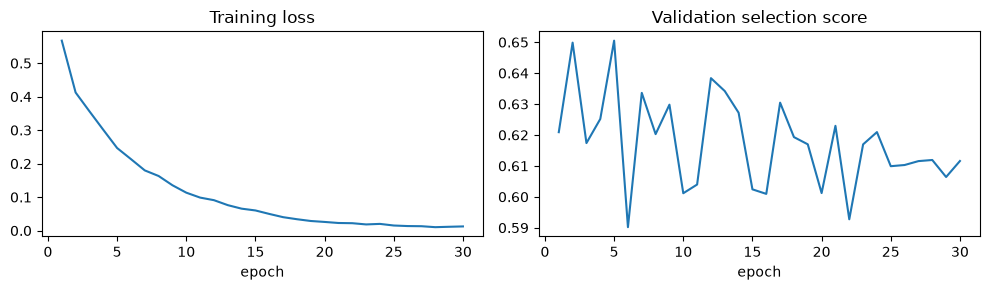

In [5]:
from src.reporting import run_status, plot_history
import json
summary, history = run_status(config["experiment_id"])
display(summary)
display(history.tail(30))
figure = plot_history(history)
if figure is not None: display(figure)
refs = ROOT/"experiments/runs"/config["experiment_id"]/"checkpoints.json"
if refs.exists(): display(json.loads(refs.read_text()))
else: print("Checkpoint artifacts: NOT CREATED")

## Summary and next step

Review the status and metrics displayed above. Missing artifacts mean **not run**, never a successful reproduction. Generated artifacts are listed in the output cells; scientific results remain separate from historical reference values.

**Next:** `03_shared_hierarchical_training.ipynb`. Preserve completed run directories, prediction files and checkpoint backups before continuing.
